In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("powerplant_data.csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
# AT =>Temperature
# V  => Vaccum
# AP => Pressure 
# RH => Humidity

In [6]:
df.isnull().sum()


AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X=df.drop("PE",axis=1)
y = df["PE"]

In [8]:
#Split out data
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test =  train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
import torch
import torch.nn as nn

In [11]:
X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)


X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [26]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [27]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

### DEEP LEARNING


In [52]:
#Define OUR ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
        #1st Hidden
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),

        # 2nd Hidden
        nn.Linear(6,6),
        nn.ReLU(),

        #output layer
        nn.Linear(6,1),
    )

    def forward(self,x):
        return self.model(x)

In [53]:
model = ANN()

import torch.optim as optim

#loss,optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [54]:
#Train the ANN
train_losses=[]
valid_losses=[]

best_val_loss = float("inf")

epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epochs


    for xb,yb in train_loader:
        #xb = features of one batch
        #yb = label of one batch

        optimizer.zero_grad()
        outputs = model(xb) # forward propagation....predicted outputs for this batch
        loss= crietrion(outputs,yb) # compute loss
        loss.backward() # backward prop...gradient is calculated 
        optimizer.step() # params update

        running_loss+=loss.item() # loss is a tensor =>py float
    epoch_training_loss = running_loss / len(train_loader)
    train_losses.append(epoch_training_loss)

    #Validation
    model.eval()
    running_val_loss=0.0
    with torch.no_grad(): #no gradient compute
        for xb,yb in test_loader:
            outputs = model(xb)
            loss= crietrion(outputs,yb)
            running_val_loss+=loss

    epoch_val_loss = running_val_loss / len(test_loader)
    valid_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> training loss ={epoch_training_loss} & val_loss = {epoch_val_loss}")
    if epoch_val_loss< best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"Best_model.pt") #.pt or .pth

epoch 1/100 ==> training loss =206755.89244791667 & val_loss = 205386.265625
epoch 2/100 ==> training loss =198669.27200520833 & val_loss = 187075.71875
epoch 3/100 ==> training loss =166784.115625 & val_loss = 141919.859375
epoch 4/100 ==> training loss =113583.88307291667 & val_loss = 85192.265625
epoch 5/100 ==> training loss =62295.63002929687 & val_loss = 43573.234375
epoch 6/100 ==> training loss =32434.171907552085 & val_loss = 24762.705078125
epoch 7/100 ==> training loss =20350.452372233074 & val_loss = 17689.310546875
epoch 8/100 ==> training loss =15479.727421061198 & val_loss = 14111.857421875
epoch 9/100 ==> training loss =12461.55226949056 & val_loss = 11388.490234375
epoch 10/100 ==> training loss =10039.489770507813 & val_loss = 9028.9375
epoch 11/100 ==> training loss =7845.073722330729 & val_loss = 6938.3212890625
epoch 12/100 ==> training loss =5919.031053670247 & val_loss = 5161.68994140625
epoch 13/100 ==> training loss =4316.536873881022 & val_loss = 3732.16674804

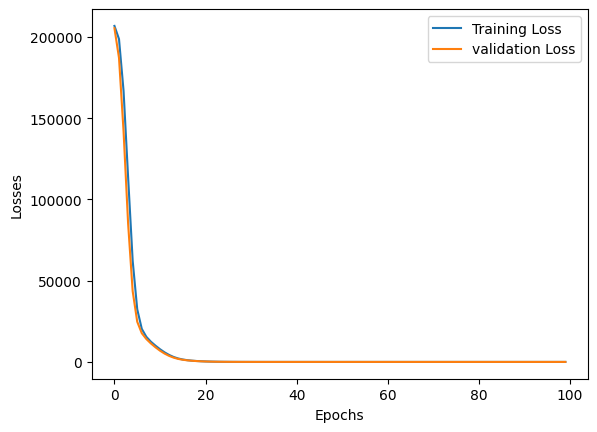

In [55]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss": valid_losses
})

plt.plot(loss_df["Training Loss"],  label = "Training Loss")
plt.plot(loss_df["Validation Loss"],label = "validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [56]:
#Loading the best model
model.load_state_dict(torch.load("Best_model.pt"))

<All keys matched successfully>

In [57]:
#Evaluation
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = crietrion(train_pred,y_train_tensor)
    test_mse_loss = crietrion(test_pred,y_test_tensor)

print("Training MSE:",train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

Training MSE: 21.318578720092773
Testing MSE: 19.531675338745117


In [58]:
from sklearn.metrics import r2_score
print(r2_score(y_test,test_pred))

0.9317418397471778


In [59]:
predicted_df = pd.DataFrame(test_pred.numpy(),columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values,columns=["Actual Values"])

pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,435.216705,433.27
1,437.111084,438.16
2,461.205292,458.42
3,476.006165,480.82
4,435.754059,441.41
...,...,...
1909,450.997253,456.70
1910,431.752319,438.04
1911,467.187042,467.80
1912,431.308197,437.14
